In [4]:
import qiskit
import qc_grader
print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")
# Check that the account has been saved properly
from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

Qiskit version: 2.1.0
Grader version: 0.22.10


{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'pBKmnV8iAo798Sana87tSpciaZMJOGZKdOVGaFB7BSZT',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/8de858de70c84169a78470eecff067c8:9a68494e-220d-495c-aed3-4fe6cfa19c88::',
  'verify': True,
  'private_endpoint': False}}

In [5]:
# Essential libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qc_grader.challenges.qgss_2025 import (
    grade_lab1_ex1_1, 
    grade_lab1_ex1_2, 
    grade_lab1_ex1_3, 
    grade_lab1_ex1_4, 
    grade_lab1_ex2, 
    grade_lab1_ex3,
    grade_lab1_ex4,
    grade_lab1_ex5,
    grade_lab1_ex6
)

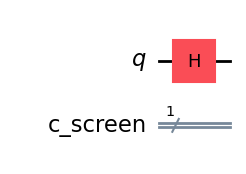

In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit = QuantumCircuit(qr, cr)
# your code here

double_slit.h(qr[0])

# end of your code
double_slit.draw('mpl')

In [7]:
grade_lab1_ex1_1(double_slit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


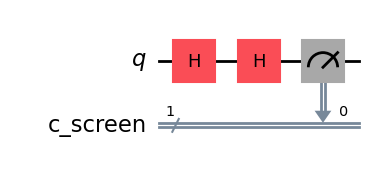

In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit = QuantumCircuit(qr, cr)
# Superposition via first Hadamard
double_slit.h(qr[0])
# Model screen with second Hadamard (no phase difference at center)
double_slit.h(qr[0])
# Measure qubit to classical register
double_slit.measure(qr[0], cr[0])
double_slit.draw('mpl')

In [9]:
grade_lab1_ex1_2(double_slit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


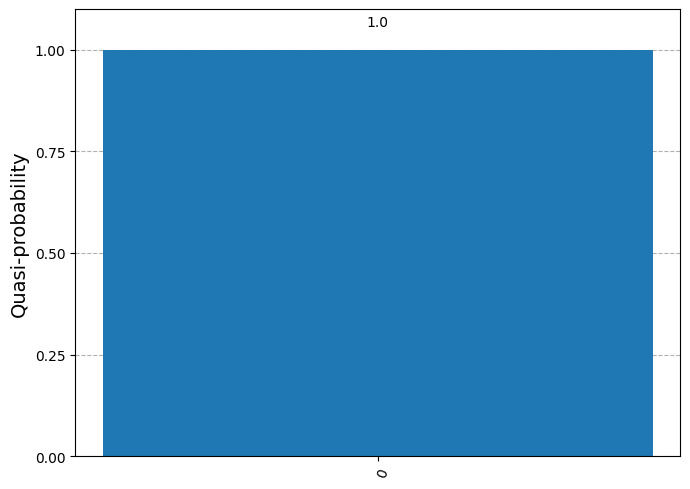

In [10]:
# use simulator
backend = AerSimulator()

# make quantum circuit compatible to the backend
pm = generate_preset_pass_manager(backend = backend, optimization_level=3)
qc_isa = pm.run(double_slit)

# run and get counts
sampler = Sampler(mode=backend)
counts = sampler.run([qc_isa], shots = 1000).result()[0].data.c_screen.get_counts()

plot_distribution(counts)

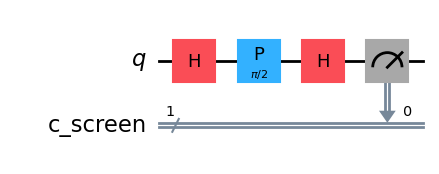

In [11]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_with_difference = QuantumCircuit(qr, cr)
double_slit_with_difference.h(0)
#your code here
# Apply phase gate P(π) to introduce phase difference to |1⟩
double_slit_with_difference.p(np.pi/2,0)
double_slit_with_difference.h(0)
double_slit_with_difference.measure(qr, cr)
double_slit_with_difference.draw('mpl')

#end of your code


Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


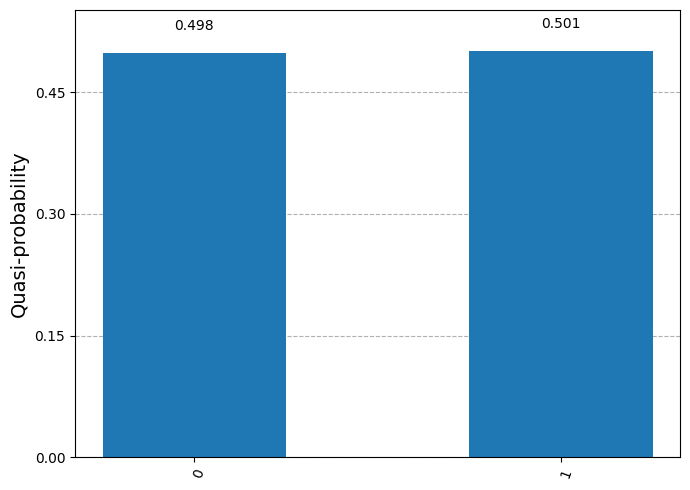

In [12]:

#double_slit_with_difference.h(0)
#double_slit_with_difference.measure(qr, cr)
#double_slit_with_difference.draw('mpl')
# Submit your answer using the following code
grade_lab1_ex1_3(double_slit_with_difference)
qc_isa = pm.run(double_slit_with_difference)

#run and get counts
sampler = Sampler(mode=backend)
counts = sampler.run([qc_isa], shots=10000).result()[0].data.c_screen.get_counts()
plot_distribution(counts)

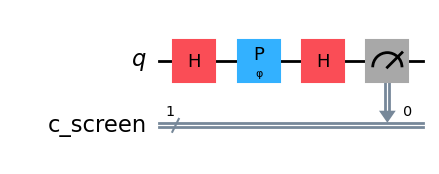

In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
import numpy as np

φ = Parameter('φ')
qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_fringe = QuantumCircuit(qr, cr)
# First Hadamard for superposition
double_slit_fringe.h(qr[0])
# Parameterized phase gate
double_slit_fringe.p(φ, qr[0])
# Second Hadamard for interference
double_slit_fringe.h(qr[0])
# Measure to c_screen
double_slit_fringe.measure(qr[0], cr[0])
double_slit_fringe.draw('mpl')


In [14]:
grade_lab1_ex1_4(double_slit_fringe)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


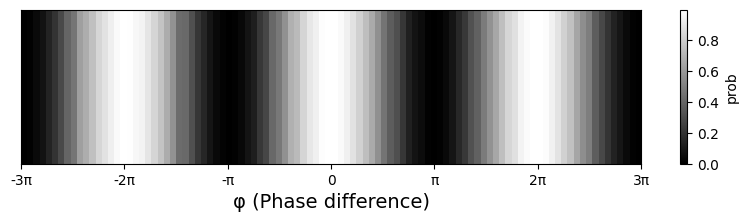

In [15]:
φ_lst = np.linspace(-3*np.pi, 3*np.pi, 100)
qc_isa = pm.run(double_slit_fringe)

φ_hit = []
dist = sampler.run([(qc_isa, φ_lst)], shots=1000).result()[0].data.c_screen

for i  in range(len(φ_lst)):
    result = dist[i].get_counts()
    if '0' in result:
        φ_hit.append(result['0']/1000)
    else:
        φ_hit.append(0)

#plot heat map
φ_hit_2d = np.array(φ_hit).reshape(1, -1)

plt.figure(figsize=(10, 2))
plt.imshow(φ_hit_2d, cmap='gray', aspect='auto', extent=[-3*np.pi, 3*np.pi, 0, 0.1])

plt.xlabel('φ (Phase difference)', fontsize=14)
plt.colorbar(label='prob')
plt.xticks(ticks=[-3*np.pi, -2*np.pi, -np.pi, 0, np.pi, 2*np.pi, 3*np.pi],
           labels=['-3π', '-2π', '-π', '0', 'π', '2π', '3π'])
plt.yticks([])  
plt.show()

In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Sampler, Batch
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import numpy as np

def schrodingers_cat_experiment_theta(theta):
    # Initialize a quantum circuit with 1 qubit
    qc = QuantumCircuit(1)
    
    # Apply RX gate with angle theta to create superposition
    qc.rx(theta, 0)
    
    # Measure the qubit (measure_all adds a classical register named 'meas')
    qc.measure_all()
    
    # Simulate the circuit with AerSimulator
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_isa = pm.run(qc)
    
    # Run the circuit with 1 shot using Sampler
    sampler = Sampler(mode=backend)
    counts = sampler.run([qc_isa], shots=1).result()[0].data.meas.get_counts()
    
    # Determine if the cat is happy (|0⟩) or grumpy (|1⟩)
    measured_state = list(counts.keys())[0] if counts else '0'
    cat_happy = (measured_state == '0')
    
    return cat_happy, qc


In [17]:
# Submit your answer (uncomment when ready)
grade_lab1_ex2(schrodingers_cat_experiment_theta)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [18]:
happy_img = Image.open('happy.png')
grumpy_img = Image.open('grumpy.png')

out = widgets.Output()

slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=2*np.pi,
    step=0.01,
    description='θ',
    continuous_update=True
)

button = widgets.Button(
    description='Open the Box',
    button_style='success'
)
    
def on_button_click(b):
    with out:
        out.clear_output(wait=True)  # clean output

        result = schrodingers_cat_experiment_theta(slider.value)[0]

        if result==True:
            img = happy_img
            txt = "happy"
        else:
            img = grumpy_img
            txt = "grumpy"

        new_size = (400, 400)
        resized_img = img.resize(new_size)
        
        buf = io.BytesIO()
        resized_img.save(buf, format='PNG')
        buf.seek(0)
        probability = int(np.cos(slider.value/2)**2 * 100)

        display(f"The probability of cat is happy: {probability}%")
        display(f"The observed cat is : {txt}")
        display(widgets.Image(value=buf.read(), format='png'))

button.on_click(on_button_click)

display(slider, button, out)

FloatSlider(value=0.0, description='θ', max=6.283185307179586, step=0.01)

Button(button_style='success', description='Open the Box', style=ButtonStyle())

Output()

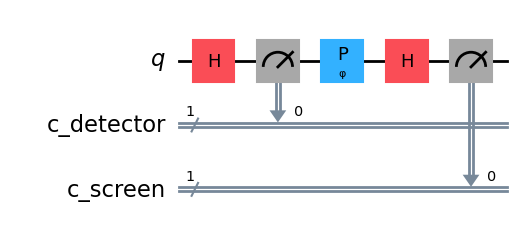

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
import numpy as np

# Setup registers
qr = QuantumRegister(1, name='q')
cr1 = ClassicalRegister(1, name='c_detector')
cr2 = ClassicalRegister(1, name='c_screen')
double_slit_with_detector = QuantumCircuit(qr, cr1, cr2)

φ = Parameter('φ')

# First Hadamard: Create superposition
double_slit_with_detector.h(qr[0])
# Which-path detector: Measure qubit to c_detector
double_slit_with_detector.measure(qr[0], cr1[0])
# Apply phase gate
double_slit_with_detector.p(φ, qr[0])
# Second Hadamard: Attempt interference
double_slit_with_detector.h(qr[0])
# Final measurement to screen
double_slit_with_detector.measure(qr[0], cr2[0])

double_slit_with_detector.draw('mpl')


In [20]:
grade_lab1_ex3(double_slit_with_detector)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


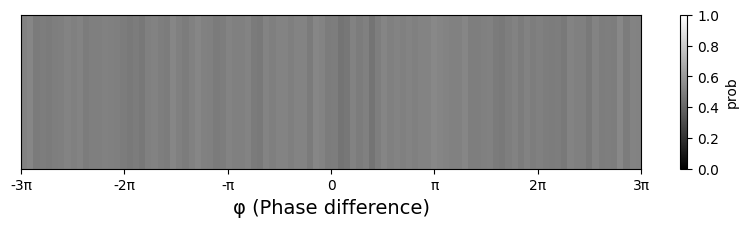

In [21]:
φ_lst = np.linspace(-3 * np.pi, 3 * np.pi, 100)
qc_isa = pm.run(double_slit_with_detector)

φ_hit = []
dist = sampler.run([(qc_isa, φ_lst)], shots=1000).result()[0].data.c_screen

for i  in range(len(φ_lst)):
    result = dist[i].get_counts()
    if '0' in result:
        φ_hit.append(result['0']/1000)
    else:
        φ_hit.append(0)

φ_hit_2d = np.array(φ_hit).reshape(1, -1)

plt.figure(figsize=(10, 2))
plt.imshow(φ_hit_2d, cmap='gray', aspect='auto', extent=[-3*np.pi, 3*np.pi, 0, 0.1], vmin=0, vmax=1)

plt.xlabel('φ (Phase difference)', fontsize=14)
plt.colorbar(label='prob')
plt.xticks(ticks=[-3 * np.pi, -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi, 3 * np.pi],
           labels=['-3π', '-2π', '-π', '0', 'π', '2π', '3π'])
plt.yticks([])  
plt.show()

In [22]:
from qiskit import QuantumCircuit
import numpy as np

def create_chsh_circuit(x, y):
    """Builds Qiskit circuit for Alice & Bob's quantum strategy."""
    qc = QuantumCircuit(2, 2, name=f'CHSH_{x}{y}') # 2 qubits, 2 classical bits

    # Task 1: Create Bell state |Φ+⟩ = (|00⟩ + |11⟩)/√2
    qc.h(0)  # Hadamard on qubit 0
    qc.cx(0, 1)  # CNOT to entangle qubits 0 and 1
    qc.barrier()

    # Step 2a: Alice's measurement basis (X if x=1, Z if x=0)
    if x == 1:
        qc.h(0)  # H for X-basis measurement

    # Task 2: Bob's measurement basis
    if y == 0:
        qc.ry(-np.pi/4, 1)  # Rotate by -π/4 for y=0
    else:
        qc.ry(np.pi/4, 1)   # Rotate by π/4 for y=1
    qc.barrier()

    # Step 3: Measure
    qc.measure([0, 1], [0, 1])  # q0 to c0 (Alice), q1 to c1 (Bob) -> 'ba' format

    return qc


In [23]:
grade_lab1_ex4(create_chsh_circuit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):


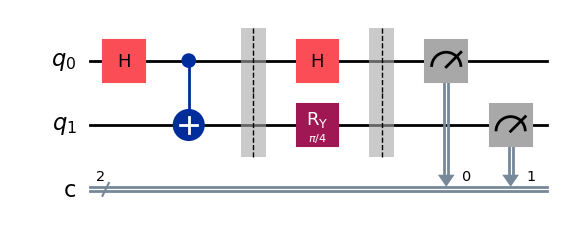

In [24]:
circuits = []
input_pairs = []
for x_in in [0, 1]:
    for y_in in [0, 1]:
        input_pairs.append((x_in, y_in))
        circuits.append(create_chsh_circuit(x_in, y_in))

print("Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):")
if len(circuits) == 4:
    display(circuits[3].draw('mpl')) # (x,y) = (1,1)
else:
    print("Circuits not generated. Run previous cell after completing Exercises 1 & 2.")

Preparing circuits for the simulator...

--- Simulation Results (Counts) ---
Inputs (x=0, y=0):
  Outcomes (ba): {'00': 474, '01': 72, '10': 64, '11': 414}
Inputs (x=0, y=1):
  Outcomes (ba): {'00': 440, '01': 77, '10': 72, '11': 435}
Inputs (x=1, y=0):
  Outcomes (ba): {'00': 449, '01': 71, '10': 69, '11': 435}
Inputs (x=1, y=1):
  Outcomes (ba): {'00': 85, '01': 430, '10': 426, '11': 83}

Plotting results...


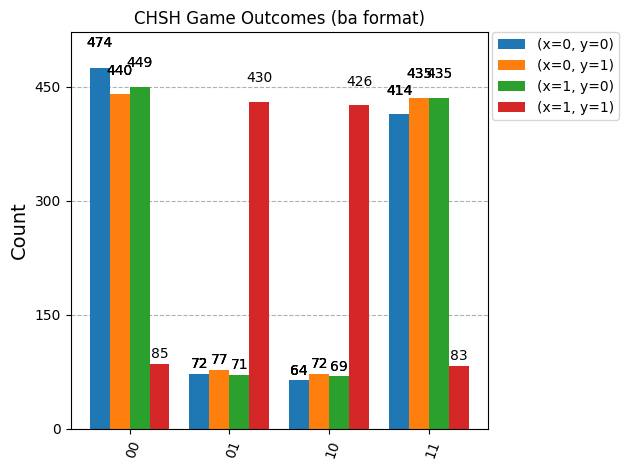

In [25]:
# AerSimulator (if not already defined)
# backend = AerSimulator()
# Pass manager (if not already defined)
# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

SHOTS = 1024

print("Preparing circuits for the simulator...")
isa_qc_chsh = pm.run(circuits)

sampler_chsh = Sampler(mode=backend) # SamplerV2
job_chsh = sampler_chsh.run(isa_qc_chsh, shots=SHOTS)
results_chsh = job_chsh.result()

# SamplerV2: results_chsh[i].data.c.get_counts() where 'c' is the default name of classical register
counts_list = [results_chsh[i].data.c.get_counts() for i in range(len(circuits))]

print("\n--- Simulation Results (Counts) ---")
for i, (x, y) in enumerate(input_pairs):
    print(f"Inputs (x={x}, y={y}):")
    sorted_counts = dict(sorted(counts_list[i].items()))
    print(f"  Outcomes (ba): {sorted_counts}")

print("\nPlotting results...")
display(plot_histogram(counts_list,
                       legend=[f'(x={x}, y={y})' for x, y in input_pairs],
                       title='CHSH Game Outcomes (ba format)'))

In [26]:
win_probabilities = {}
print("--- Calculating Win Probabilities ---")

for i, (x, y) in enumerate(input_pairs):
    counts = counts_list[i]

    # Task 1: Target (a XOR b) value for winning
    target_xor_result = x and y  # a XOR b should equal x AND y

    wins_for_this_case = 0

    # Task 2: Calculate wins
    for outcome, count in counts.items():
        b, a = int(outcome[0]), int(outcome[1])  # 'ba' format
        if (a ^ b) == target_xor_result:  # Check if a XOR b matches target
            wins_for_this_case += count

    prob = wins_for_this_case / SHOTS if SHOTS > 0 else 0
    win_probabilities[(x, y)] = prob
    print(f"Inputs (x={x}, y={y}): Target (a XOR b) = {target_xor_result}. Win Probability = {prob:.4f}")

avg_win_prob = sum(win_probabilities.values()) / 4.0
P_win_quantum_theory = np.cos(np.pi / 8)**2  # ~0.8536
P_win_classical_limit = 0.75

print("\n--- Overall Performance ---")
print(f"Experimental Average Win Probability: {avg_win_prob:.4f}")
print(f"Theoretical Quantum Win Probability: {P_win_quantum_theory:.4f}")
print(f"Classical Limit Win Probability:     {P_win_classical_limit:.4f}")


--- Calculating Win Probabilities ---
Inputs (x=0, y=0): Target (a XOR b) = 0. Win Probability = 0.8672
Inputs (x=0, y=1): Target (a XOR b) = 0. Win Probability = 0.8545
Inputs (x=1, y=0): Target (a XOR b) = 0. Win Probability = 0.8633
Inputs (x=1, y=1): Target (a XOR b) = 1. Win Probability = 0.8359

--- Overall Performance ---
Experimental Average Win Probability: 0.8552
Theoretical Quantum Win Probability: 0.8536
Classical Limit Win Probability:     0.7500


In [27]:
grade_lab1_ex5(counts_list, avg_win_prob)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


Full Teleportation Circuit:


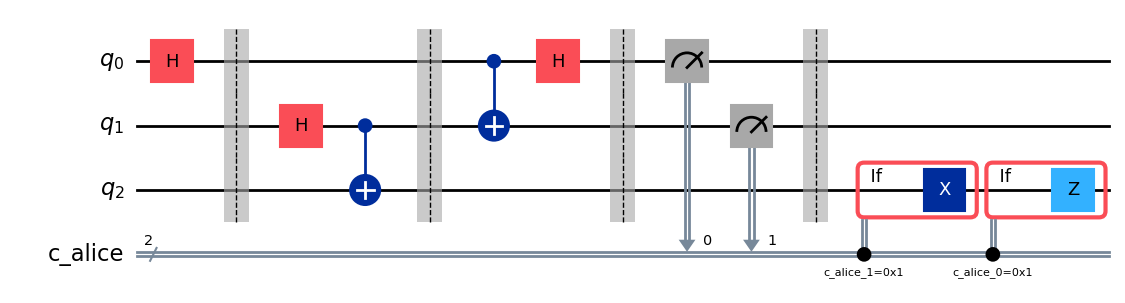

In [28]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Define registers
qr_tele = QuantumRegister(3, name='q')
cr_alice_tele = ClassicalRegister(2, name='c_alice')
teleport_qc = QuantumCircuit(qr_tele, cr_alice_tele, name='Teleportation')

# Prepare Alice's message state |+⟩ on q0
teleport_qc.h(qr_tele[0])
teleport_qc.barrier()

# Task 1: Create Bell pair between q1 (Alice) and q2 (Bob)
teleport_qc.h(qr_tele[1])
teleport_qc.cx(qr_tele[1], qr_tele[2])
teleport_qc.barrier()

# Task 2: Alice's Bell measurement gates
teleport_qc.cx(qr_tele[0], qr_tele[1])
teleport_qc.h(qr_tele[0])
teleport_qc.barrier()

# Alice measures her qubits
teleport_qc.measure(qr_tele[0], cr_alice_tele[0])  # q0 -> c0
teleport_qc.measure(qr_tele[1], cr_alice_tele[1])  # q1 -> c1
teleport_qc.barrier()

# Task 3: Bob's conditional corrections
with teleport_qc.if_test((cr_alice_tele[1], 1)):
    teleport_qc.x(qr_tele[2])  # Apply X if c1=1
with teleport_qc.if_test((cr_alice_tele[0], 1)):
    teleport_qc.z(qr_tele[2])  # Apply Z if c0=1

print("Full Teleportation Circuit:")
display(teleport_qc.draw('mpl'))


In [29]:
grade_lab1_ex6(teleport_qc)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


Using statevector simulator...
Running statevector simulation...
Simulation successful.
Statevector retrieved successfully.

Visualizing final qubit states (q2 should match initial q0 state |+>):


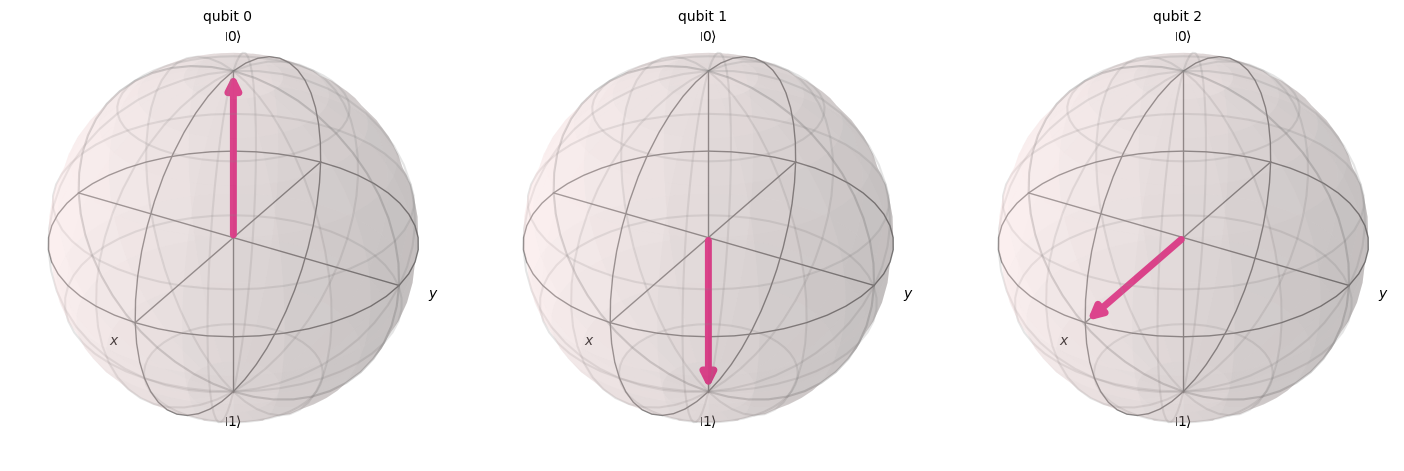

In [30]:

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector

# Use Statevector Simulator
print("Using statevector simulator...")
sv_simulator = AerSimulator(method='statevector')
teleport_qc_sv = teleport_qc.copy()
teleport_qc_sv.save_statevector()

print("Running statevector simulation...")
job_sv = sv_simulator.run(teleport_qc_sv)
result_sv = job_sv.result()

if result_sv.success:
    print("Simulation successful.")
    final_statevector = result_sv.get_statevector()
    print("Statevector retrieved successfully.")
    print("\nVisualizing final qubit states (q2 should match initial q0 state |+>):")
    display(plot_bloch_multivector(final_statevector))
else:
    print(f"Statevector simulation failed! Status: {result_sv.status}")

In [31]:
#Check your submission status with the code belowf
from qc_grader.grader.grade import check_lab_completion_status
check_lab_completion_status("qgss_2025")

Lab 0: 2/2 exercises completed (100%)
    ✅ 2153 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 1548 participants have completed this lab
Lab 2: 7/7 exercises completed (100%)
    ✅ 810 participants have completed this lab
Lab 3: 5/5 exercises completed (100%)
    ✅ 534 participants have completed this lab
Lab 4: 6/6 exercises completed (100%)
    ✅ 273 participants have completed this lab
Functions Labs: 0/8 exercises completed (0%)
    ✅ 2 participants have completed this lab
